# Trayectos desde el aeropuerto para taxis

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, se necesita predecir la cantidad de pedidos de taxis para la próxima hora. A continuación se construye y compara distintos modelos de series temporales para dicha predicción.

Como requisito se solicita que la métrica RECM en el conjunto de prueba no supere 48.

## Instrucciones del proyecto.

1. De los datos hacer el remuestreo por una hora.
2. Analizar los datos
3. Entrenar diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.
4. Probar los datos usando la muestra de prueba y proporcionar una conclusión.


# Contenido <a id='back'></a>

* [Etapa 1. Preparación de los datos](#data_review)
* [Etapa 2. Analisis Exploratorio de datos](#eda)
* [Etapa 3. Ingenieria de características](#feature_eng)
* [Etapa 4. Implementación de modelos de series temporales](#models)
    * [Modelo de regresión lineal](lineal_regresion)
    * [Modelo de Bosques Aleatorios](#random_forest)
    * [Modelo CatBoostRegression](#catboost)
* [Conclusiones](#end)

## Etapa 1. Preparación de los datos <a id='data_review'></a>

In [38]:
#importacion de librerias necesarias
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import numpy as np
import math
from lightgbm import LGBMRegressor
!pip install xgboost

In [3]:
#lectura de dataset, convirtinedo a tipo datetime el indice
data=pd.read_csv('taxi.csv', parse_dates=[0], index_col=[0]) #parse_dates para asegurar que los datos estén correctamente indexados por tiempo desde la carga del archivo. Esto es fundamental para el análisis de series temporales que realizarás más adelante.

In [4]:
# imprimir primeras columnas para corroborar correcta lectura
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [5]:
#lectura de info
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


## Etapa 2. Analisis Exploratorio de Datos <a id='eda'></a>

<Axes: xlabel='datetime'>

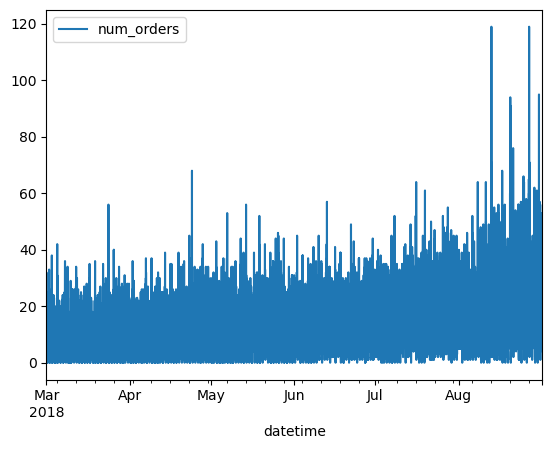

In [6]:
# grafico de datos 
data.plot(kind='line')

In [8]:
# reagrupacion de datos para que se sumen los datos en periodos de cada hora
data_group_hour= data.resample('1h').sum()

<Axes: xlabel='datetime'>

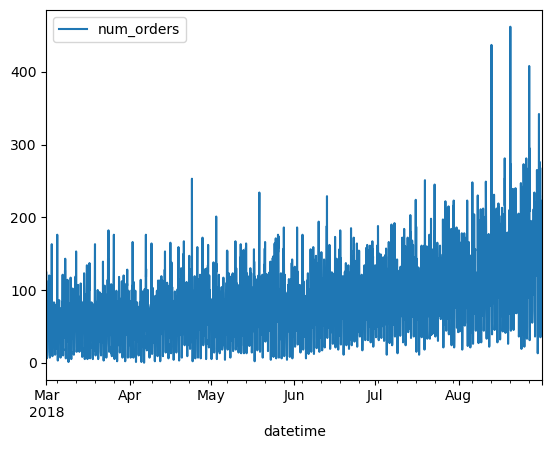

In [9]:
# grafico de datos
data_group_hour.plot(kind='line')

In [10]:
# reagrupamiento de datos para la suma por dia
data_group_day= data.resample('1D').sum()

<Axes: xlabel='datetime'>

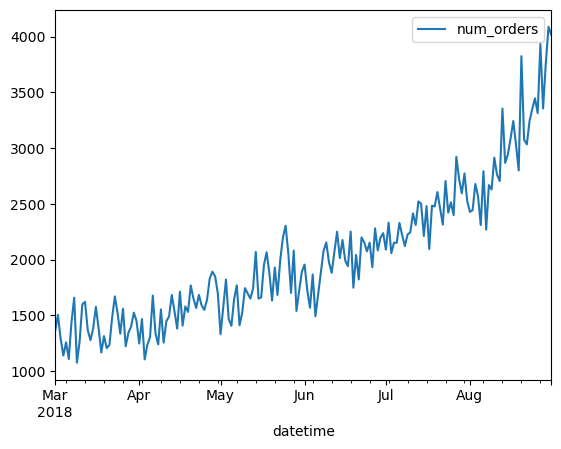

In [11]:
#grafico de datos
data_group_day.plot(kind='line')

In [12]:
#Estacionalidad = patron en tiempo
#Tendencia= donde crece o decrece
data_decompuesta=seasonal_decompose(data_group_hour)
print(data_decompuesta)

De la grafica expuesta se observa que exite una tendencia a la alta conforma van avanzando los meses en el año, teniendo la menor cantidad de viajes en marzo y creciendo  continuamente cada mes, hasta alcanzar la mayor cantidad de viajes en agosto, incluso duplicando los viajes de marzo, tambien se puede observar que el alza exponencial empeiza en el mes de junio. La estacionalidad se puede observar en el corto plazo cada 7 dias en conde hay picos altos y bajadas cada ciertos días, mismos que se presentan en marzo y se los picos y valles se intencifican en agosto. Debido a que solo se cuenta con datos de 6 meses del año, no se puede hablar de una estacionalidad anual. 

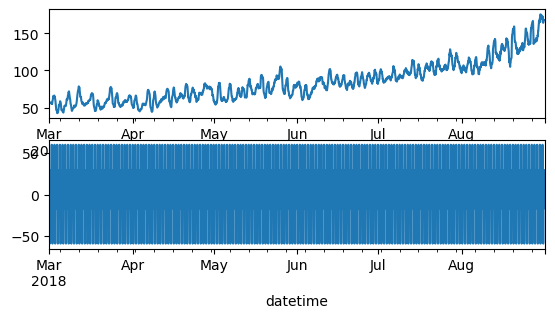

In [16]:
#grafica de tendencia y de estacionalidad
plt.figure()
plt.subplot(311)
data_decompuesta.trend.plot(ax=plt.gca())
plt.subplot(312)
data_decompuesta.seasonal.plot(ax=plt.gca())
plt.show()

#se observa una tendencia creciente

Mismas inferencias detectadas arriba se comprubas con estas graficas donde se observa la tendencia a la alta conforma avanzan los meses del año, acerca de la estacionalidad se observa que el patron es diario con alzas y bajas.

<Axes: xlabel='datetime'>

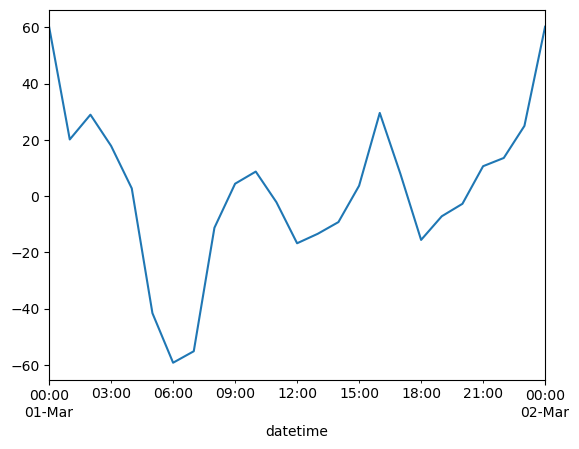

In [19]:
#grafico de estacionalidad para perido de tiempo menor al 2 de marzo, solo primer dia de datos
data_decompuesta.seasonal[data_decompuesta.seasonal.index <= '2018-03-02'].plot()

Se observa que existe una tendencia en donde existe una solicitud muy grande de taxis entre las 0 y 3 am, despues empieza a bajar la demanda hasta alcanzar su punto mas bajo a las 6 am para despues volver a crecer teniendo un pico a las 9 am, esto se puede deber una baja recepcion de vuelos a las 6 de la mañana, que incrementa para las 9 am donde puede haber mas llegada de vuelos, al igual que a las 3 pm.

<Axes: xlabel='datetime'>

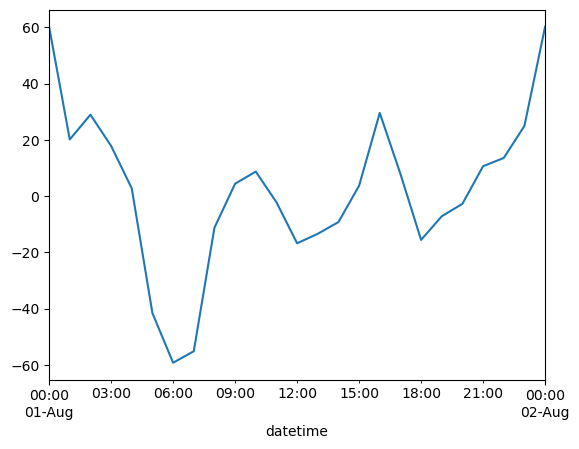

In [20]:
#Grafico para observar tendencia un dia despues 
data_decompuesta.seasonal[(data_decompuesta.seasonal.index >= '2018-08-01') & (data_decompuesta.seasonal.index <= '2018-08-02')].plot()

#muestra misma tendencia al dia anterior en las horas pico de demanda de taxis

Se observa que tenemos el mismo patron de comportamiento en el dis posterior teniendo alzas por la noche y bajas durante la madrugada hasta llegar a la mañana.

## Etapa 3. Ingenieria de características <a id='feature_eng'></a>

In [21]:
#Agrupamos numero de pedidos por mes dia, dia de la semana y hora
data_group_hour['mes']= data_group_hour.index.month
data_group_hour['dia']= data_group_hour.index.day
data_group_hour['dia_de_la_semana']= data_group_hour.index.dayofweek
data_group_hour['hour']= data_group_hour.index.hour
print(data_group_hour)

                     num_orders  mes  dia  dia_de_la_semana  hour
datetime                                                         
2018-03-01 00:00:00         124    3    1                 3     0
2018-03-01 01:00:00          85    3    1                 3     1
2018-03-01 02:00:00          71    3    1                 3     2
2018-03-01 03:00:00          66    3    1                 3     3
2018-03-01 04:00:00          43    3    1                 3     4
...                         ...  ...  ...               ...   ...
2018-08-31 19:00:00         136    8   31                 4    19
2018-08-31 20:00:00         154    8   31                 4    20
2018-08-31 21:00:00         159    8   31                 4    21
2018-08-31 22:00:00         223    8   31                 4    22
2018-08-31 23:00:00         205    8   31                 4    23

[4416 rows x 5 columns]


In [22]:
#creacion de caracteristicas, desfase y media movil
for lag in range(1, 6):
    data_group_hour[f'lag_{lag}']=data_group_hour['num_orders'].shift(lag)

data_group_hour['promedio_movil']=data_group_hour['num_orders'].shift().rolling(3).mean()
data_group_hour.dropna(inplace=True)
print(data_group_hour)

                     num_orders  mes  dia  dia_de_la_semana  hour  lag_1  \
datetime                                                                   
2018-03-01 05:00:00           6    3    1                 3     5   43.0   
2018-03-01 06:00:00          12    3    1                 3     6    6.0   
2018-03-01 07:00:00          15    3    1                 3     7   12.0   
2018-03-01 08:00:00          34    3    1                 3     8   15.0   
2018-03-01 09:00:00          69    3    1                 3     9   34.0   
...                         ...  ...  ...               ...   ...    ...   
2018-08-31 19:00:00         136    8   31                 4    19  207.0   
2018-08-31 20:00:00         154    8   31                 4    20  136.0   
2018-08-31 21:00:00         159    8   31                 4    21  154.0   
2018-08-31 22:00:00         223    8   31                 4    22  159.0   
2018-08-31 23:00:00         205    8   31                 4    23  223.0   

           

El desfase (lags) y medias moviles son importantes como caracteristicas dentro de nuestros datos para transformar el tiempo en variables numéricas estructuradas de forma que un modelo tradicional de Machine Learning (como una Regresión Lineal o un Bosque Aleatorio) pueda entender el pasado y usarlo para predecir el futuro. Las series de tiempo nativas  uoriginales solo tienen dos columnas: la fecha/hora y el valor. Al aplicar estas técnicas, se extrae un comportamiento histórico y se crean "pistas" matemáticas para el algoritmo.
Una media móvil calcula el promedio de un grupo de datos dentro de una "ventana" de tiempo que se va deslizando periodo a periodo. De esta forma se puede conocer cual es el comportamiento general y la dirección en la que van los datos, otr funcion de la media movil, es eliminar el ruido las fluctuaciones por el azar de un dia lluvioso, al suavisar las anamalias y mostrar la tendencia real ais como mostrar la velocidad actual de crecimiento. 

## Etapa 4. Implementacion de modelos <a id='models'></a>

In [23]:
#dividir conjunto de entrenamiento, validación y prueba
train_valid, test= train_test_split(data_group_hour, shuffle=False, test_size=0.1)
train, valid = train_test_split(train_valid, shuffle=False, test_size=0.1)

In [29]:
#comprobar la correcta division de conjuntos
print(len(train))
print()
print(len(valid))
print()
print(len(test))
print()
print(len(data_group_hour))

3572

397

442

4411


In [30]:
#Verificacion cronológica (indispensable para series temporales)
# se extrae las fechas directamente de los subconjuntos correspondientes.
print("--- VERIFICACIÓN CRONOLÓGICA (LÍNEA TEMPORAL) ---")

# como se dividió usando índices de Pandas
print(f"Entrenamiento : Desde {train.index.min()} hasta {train.index.max()}")
print(f"Validación    : Desde {valid.index.min()} hasta {valid.index.max()}")
print(f"Prueba        : Desde {test.index.min()} hasta {test.index.max()}")

# Comprobación de orden secuencial
if train.index.max() < valid.index.min() and valid.index.max() < test.index.min():
   print("✅ ¡Perfecto! Los conjuntos están ordenados en el tiempo cronológicamente.")
else:
    print("❌ ERROR DE DATA LEAKAGE: Los conjuntos se mezclaron o se enciman en sus fechas.")
print("-------------------------------------------------") 

--- VERIFICACIÓN CRONOLÓGICA (LÍNEA TEMPORAL) ---
Entrenamiento : Desde 2018-03-01 05:00:00 hasta 2018-07-28 00:00:00
Validación    : Desde 2018-07-28 01:00:00 hasta 2018-08-13 13:00:00
Prueba        : Desde 2018-08-13 14:00:00 hasta 2018-08-31 23:00:00
✅ ¡Perfecto! Los conjuntos están ordenados en el tiempo cronológicamente.
-------------------------------------------------


In [31]:
#definir caracteristicas y objetivos
features_train = train.drop(['num_orders'], axis=1)
target_train = train['num_orders']
features_valid = valid.drop(['num_orders'], axis=1)
target_valid = valid['num_orders']
features_test = test.drop(['num_orders'], axis=1)
target_test = test['num_orders']

## Modelo regresion lineal <a id='lineal_regresion'></a>

In [32]:
modelo_rl = LinearRegression()
modelo_rl.fit(features_train, target_train)

pred_train=modelo_rl.predict(features_train)
print(f'El error del modelo con los datos de entrenamiento es de:{mean_squared_error(target_train, pred_train)**0.5}')
print()
pred_valid= modelo_rl.predict(features_valid)
print(f'El error del modelo con los datos de validacion es de:{mean_squared_error(target_valid, pred_valid)**0.5}')
print()
pred_test= modelo_rl.predict(features_test)
print(f'El error del modelo con los datos de prueba es de:{mean_squared_error(target_test, pred_test)**0.5}')


El error del modelo con los datos de entrenamiento es de:29.176656280301064

El error del modelo con los datos de validacion es de:40.6645293934645

El error del modelo con los datos de prueba es de:53.30659186854296


## Modelo de Bosques aleatorios <a id='random_forest'></a>

In [33]:
model_rf= RandomForestRegressor(n_estimators=5000, max_depth=32)
model_rf.fit(features_train, target_train)
pred_valid_rf=model_rf.predict(features_valid)

print(f'El error del modelo con los datos de validacion es de:{mean_squared_error(target_valid, pred_valid_rf)**0.5}')
print()
pred_test_rf= model_rf.predict(features_test)
print(f'El error del modelo con los datos de prueba es de:{mean_squared_error(target_test, pred_test_rf)**0.5}')


El error del modelo con los datos de validacion es de:33.381416671439055

El error del modelo con los datos de prueba es de:52.899600002786805


## Modelo CatBoostRegressor <a id='catboost'></a>

In [34]:
#Funcion para determinar el mean squared error
def rnse(real, prediccion):
  mse= mean_squared_error(real, prediccion)
  rmse= math.sqrt(mse)
  return rmse

In [36]:
#predicciones con modelo matricial de CatboostRegressor con variables categoricas transformadas
model_cat= CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1)
model_cat.fit(features_train, target_train)

predicciones_train_cat=model_cat.predict(features_train)
predicciones_valid_cat=model_cat.predict(features_valid)
predicciones_test_cat=model_cat.predict(features_test)

print('RMSE train:', rnse(target_train, predicciones_train_cat))
print('RMSE valid:', rnse(target_valid, predicciones_valid_cat))
print('RMSE test:', rnse(target_test, predicciones_test_cat))


0:	learn: 34.5941883	total: 2.72ms	remaining: 1.36s
1:	learn: 33.0680774	total: 5.4ms	remaining: 1.34s
2:	learn: 31.8171751	total: 8.47ms	remaining: 1.4s
3:	learn: 30.8088792	total: 10.9ms	remaining: 1.35s
4:	learn: 29.9151358	total: 13.1ms	remaining: 1.3s
5:	learn: 29.1732579	total: 15.3ms	remaining: 1.26s
6:	learn: 28.4249064	total: 17.7ms	remaining: 1.24s
7:	learn: 27.7012884	total: 20ms	remaining: 1.23s
8:	learn: 27.1006996	total: 22.4ms	remaining: 1.22s
9:	learn: 26.5774229	total: 24.9ms	remaining: 1.22s
10:	learn: 26.2284963	total: 27.3ms	remaining: 1.22s
11:	learn: 25.7580725	total: 29.6ms	remaining: 1.2s
12:	learn: 25.3313758	total: 31.9ms	remaining: 1.19s
13:	learn: 24.9993482	total: 34.1ms	remaining: 1.19s
14:	learn: 24.7315063	total: 36.3ms	remaining: 1.17s
15:	learn: 24.3906050	total: 38.5ms	remaining: 1.17s
16:	learn: 24.2167792	total: 41.4ms	remaining: 1.18s
17:	learn: 24.0142333	total: 44.6ms	remaining: 1.2s
18:	learn: 23.7828784	total: 47.2ms	remaining: 1.2s
19:	learn: 

## Modelo LightGBM <a id='lightgbm'></a>

In [39]:
#predicciones con modelo LighGBM
model_lighgbm= LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.15,
    random_state=12345)
model_lighgbm.fit(features_train, target_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1211
[LightGBM] [Info] Number of data points in the train set: 3572, number of used features: 10
[LightGBM] [Info] Start training from score 74.753639


,learning_rate,0.15
,n_estimators,1000
,random_state,12345
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [40]:
predicciones_train_lgbm=model_lighgbm.predict(features_train)
predicciones_valid_lgbm=model_lighgbm.predict(features_valid)
predicciones_test_lgbm=model_lighgbm.predict(features_test)

print('RMSE train:', rnse(target_train, predicciones_train_lgbm))
print('RMSE valid:', rnse(target_valid, predicciones_valid_lgbm))
print('RMSE test:', rnse(target_test, predicciones_test_lgbm))

RMSE train: 0.9018331516049346
RMSE valid: 34.619496427210336
RMSE test: 55.33446260813328


## Conclusion <a id='end'></a>

Despues de la preparacion de datos, completar las caracteristicas y probar distintos modelos, los resultados indican que la rais del error cuadratico medio es de 53.30 pedidos para el modelo de regresion lineal, de 52.89 pedidos para Bosques aletorios y de 54.97 para las pruebas con modelo Catboost y de 55.33 con LightGBM. Esto nos indica que el mejor modelo fue  Bosqueas aleatorios.

El enfoque que ayudó al procesamiento de los datos al reagrupar los datos por hora. Esto es crucial para el análisis de series temporales y para preparar los datos para futuras operaciones de modelado o descomposición.

A partir de estos modelos matemáticos podemos predecir con un error de 52 viajes, la cantidad de taxis que se necesitan tener disponibles para realizar viajes desde el aeropuerto por cada hora transcurrida en el día. Esto representa mayor conocimiento para la empresa de taxis y organización de sus flotilla de coches asi como de insumos y mejora en la atención a clientes. 